Importing required library and functions

In [1]:
import sys
import os
import re
import shutil
import psutil
import platform
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt;
import pyemu
import flopy
assert "dependencies" in flopy.__file__
assert "dependencies" in pyemu.__file__
# herebedragons.py contains a series of utility functions that help us 
sys.path.insert(0,"..")
import herebedragons as hbd
from scipy.interpolate import griddata, RegularGridInterpolator
import skgstat as skg


Setting up MODFLOW files dir

Getting executables to run PEST

In [2]:
# folder containing original model files
org_d = os.path.join('..', '..', '..', "results", '3d_injection_modeling_PMW-6')

# a dir to hold a copy of the org model files
tmp_d = os.path.join('PMW-6_mf6')

if os.path.exists(tmp_d):
    shutil.rmtree(tmp_d)
shutil.copytree(org_d,tmp_d)

# get executables
hbd.prep_bins(tmp_d)
# get dependency folders
hbd.prep_deps(tmp_d)

In [3]:
sim_ws = os.path.join('..', '..', '..', "results", "3d_injection_modeling_PMW-6")
os.listdir(tmp_d)

['heads.csv',
 'inschek.exe',
 'k_layer1.txt',
 'k_layer2.txt',
 'k_layer3.txt',
 'mf5to6.exe',
 'mf6.exe',
 'mfsim.lst',
 'mfsim.nam',
 'MLAC-model.bud',
 'MLAC-model.chd',
 'MLAC-model.dis',
 'MLAC-model.dis.grb',
 'MLAC-model.hds',
 'MLAC-model.ic',
 'MLAC-model.ims',
 'MLAC-model.lst',
 'MLAC-model.nam',
 'MLAC-model.npf',
 'MLAC-model.obs',
 'MLAC-model.oc',
 'MLAC-model.sto',
 'MLAC-model.tdis',
 'MLAC-model.wel',
 'mp7.exe',
 'pest.exe',
 'pestchek.exe',
 'pestpp-da.exe',
 'pestpp-glm.exe',
 'pestpp-ies.exe',
 'pestpp-mou.exe',
 'pestpp-opt.exe',
 'pestpp-sen.exe',
 'pestpp-swp.exe',
 'simulated_data',
 'tempchek.exe',
 'well_location_and_times.csv',
 'zbud6.exe']

Loading MODFLOW simulation to obtain discretization information

In [4]:
sim = flopy.mf6.MFSimulation.load(sim_ws=tmp_d)
gwf = sim.get_model()

#pyemu.os_utils.run("mf6", cwd=tmp_d, verbose=True)

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


Spatial reference

In [5]:
#grid_length_x = gwf.dis.delr.array.sum()
grid_length_y = gwf.dis.delc.array.sum()
topleft_yorigin = gwf.dis.yorigin.array + grid_length_y
proj4 = '+proj=utm +zone=15 +datum=NAD83 +units=m +no_defs +type=crs'
sr = pyemu.helpers.SpatialReference(
    delr=gwf.dis.delr.array, 
    delc=gwf.dis.delc.array,
    xul=gwf.dis.xorigin.array, 
    yul=topleft_yorigin, 
    proj4_str=proj4,
)

Instantiate PstFrom

In [6]:
template_ws = os.path.join("PMW-6_template") #template directory (PstFrom working folder)
start_datetime = "08/29/2024"

#instantiate PstFrom
pf = pyemu.utils.PstFrom(
    original_d = tmp_d, #where the model is stored
    new_d = template_ws, #where the PEST template will be stored
    longnames = False, #for using PEST/PEST_HP
    spatial_reference = sr, #spatial reference from the model
    zero_based = False, #MODFLOW does not use zero based indices
    start_datetime = start_datetime, #for temporal correlation between parameters
    echo=True, 
    remove_existing=True, #remove existing files in the template directory
)

2025-10-30 12:29:59.649622 starting: opening PstFrom.log for logging
2025-10-30 12:29:59.649622 starting PstFrom process
2025-10-30 12:29:59.671972 starting: setting up dirs
2025-10-30 12:29:59.671972 starting: removing existing new_d 'PMW-6_template'
2025-10-30 12:29:59.866641 finished: removing existing new_d 'PMW-6_template' took: 0:00:00.194669
2025-10-30 12:29:59.866641 starting: copying original_d 'PMW-6_mf6' to new_d 'PMW-6_template'
2025-10-30 12:30:02.145181 finished: copying original_d 'PMW-6_mf6' to new_d 'PMW-6_template' took: 0:00:02.278540
2025-10-30 12:30:02.145181 finished: setting up dirs took: 0:00:02.473209


pf

Adjusting heads.csv file to match field data times

In [7]:
import flopy.utils.binaryfile as bf
"""
Reads the MODFLOW binary heads file, extracts heads for specified
observation wells at desired times, interpolating between time steps
if necessary, and saves the data to heads.csv.
"""

model_name = "MLAC-model"

file_path = os.path.join(template_ws, 'well_location_and_times.csv')

# --- Load observation info from the CSV file ---
try:
    obs_df = pd.read_csv(file_path)

except FileNotFoundError:
    raise FileNotFoundError("well_locations.csv not found. Did you run create_model.py?")

# Check if the .hds file exists before attempting to read
hds_filepath = os.path.join(template_ws, f'{model_name}.hds')
if not os.path.exists(hds_filepath):
    raise FileNotFoundError(f"Binary heads file not found: {hds_filepath}")

hds_file = bf.HeadFile(hds_filepath)
model_output_times = np.array(hds_file.get_times())

# Get the unique well names and locations
well_locations = obs_df[['well_name', 'layer', 'row', 'col']].drop_duplicates()

# Prepare results storage
interpolated_results = []

for index, obs in obs_df.iterrows():
    well_name = obs['well_name']
    layer, row, col = obs['layer'], obs['row'], obs['col']
    target_time = obs['time']

    # Find the time steps in the model output that bracket the target_time
    # Use np.searchsorted for efficient finding of insertion points
    idx = np.searchsorted(model_output_times, target_time)

    # Handle edge cases: target_time is before the first or after the last model output time
    if idx == 0:
        # Target time is at or before the first model output time.
        # Use the first time step's head.
        # You might want to raise a warning or handle this differently (e.g., extrapolation if allowed).
        t1 = model_output_times[0]
        heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
        interpolated_head = heads_data_t1
        print(f"Warning: Target time {target_time} is before or at first model time {t1}. Using head at {t1}.")

    elif idx == len(model_output_times):
        # Target time is at or after the last model output time.
        # Use the last time step's head.
        # You might want to raise a warning or handle this differently.
        t1 = model_output_times[-1]
        heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
        interpolated_head = heads_data_t1
        print(f"Warning: Target time {target_time} is at or after last model time {t1}. Using head at {t1}.")

    else:
        # Target time is between two model output times or exactly at one.
        t1 = model_output_times[idx - 1]
        t2 = model_output_times[idx]

        if target_time == t1:
            # Exact match for the lower bound
            heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
            interpolated_head = heads_data_t1
        elif target_time == t2:
            # Exact match for the upper bound
            heads_data_t2 = hds_file.get_data(totim=t2)[layer, row, col]
            interpolated_head = heads_data_t2
        else:
            # Interpolate between t1 and t2
            heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
            heads_data_t2 = hds_file.get_data(totim=t2)[layer, row, col]

            # Linear interpolation formula
            interpolated_head = heads_data_t1 + (heads_data_t2 - heads_data_t1) * \
                                (target_time - t1) / (t2 - t1)
    
    interpolated_results.append({
        'time': target_time,
        'well_name': f'HEAD_{well_name}',
        'head': interpolated_head
    })

# Create and pivot the DataFrame
results_df = pd.DataFrame(interpolated_results)

# Pivot the data to have columns for each well name
output_df = results_df.pivot(index='time', columns='well_name', values='head')

# Sort by time, reset index for clean CSV, and ensure consistent output column order
output_df = output_df.sort_index().reset_index()

desired_order = ['time', 'HEAD_PW-1', 'HEAD_PMW-3', 'HEAD_PMW-10', 'HEAD_PMW-14',
                    'HEAD_PW-2', 'HEAD_PMW-9', 'HEAD_PZ-1', 'HEAD_PMW-4', 'HEAD_PMW-5',
                    'HEAD_OW24P', 'HEAD_OW23P', 'HEAD_OW17P']

# Select the columns in the specified order
# Note: If a column is in desired_order but not in output_df, it will be added as NaN.
# If a column is in output_df but not in desired_order, it will be dropped.
try:
    output_df = output_df[desired_order]
except KeyError as e:
    print(f"Warning: A column was not found during reordering: {e}")
    # Continue saving, but without the specified order if it fails

# Write to CSV
output_df.to_csv(os.path.join(template_ws, 'heads.csv'), index=False, float_format='%.16E')
print("heads.csv created with interpolated head data at specified times.")

heads.csv created with interpolated head data at specified times.


Checking data from MODFLOW

In [8]:
#checking the output csv files
for i in [gwf.obs]: 
    print(i.output.obs_names)

['heads.csv']


taking a look at the data file

In [9]:
df_modflow = pd.read_csv(os.path.join(template_ws, "heads.csv"), index_col=0)
df_modflow.head()

,HEAD_PW-1,HEAD_PMW-3,HEAD_PMW-10,HEAD_PMW-14,HEAD_PW-2,HEAD_PMW-9,HEAD_PZ-1,HEAD_PMW-4,HEAD_PMW-5,HEAD_OW24P,HEAD_OW23P,HEAD_OW17P
time,,,,,,,,,,,,
0.010417,0.020916,0.082986,0.099070,0.067635,0.077078,0.019033,0.045098,0.009717,0.026818,0.026691,0.110870,0.016515
0.020833,0.046839,0.123527,0.140921,0.106017,0.116659,0.044048,0.079158,0.028729,0.056122,0.056204,0.154632,0.040597
0.041667,0.081487,0.166799,0.184479,0.147901,0.159087,0.078432,0.118614,0.058585,0.092631,0.092736,0.199044,0.074118
0.062500,0.103825,0.192060,0.209663,0.172646,0.183869,0.100882,0.142682,0.079221,0.115362,0.114763,0.224219,0.095499


Taking a look at the field data

In [10]:
df_field = pd.read_csv("../../../data/PMW-6_t.csv", index_col=0)
df_field.head()

,HEAD_PW-1,HEAD_PMW-3,HEAD_PMW-10,HEAD_PMW-14,HEAD_PW-2,HEAD_PMW-9,HEAD_PZ-1,HEAD_PMW-4,HEAD_PMW-5,HEAD_OW24P,HEAD_OW23P,HEAD_OW17P
time,,,,,,,,,,,,
0.010417,0.009313,0.139853,0.005000,0.110165,0.00136,0.000,0.019109,-0.002393,0.006000,0.003426,0.021026,0.005726
0.020833,0.035997,0.203853,0.028999,0.180839,-0.00022,-0.001,0.063277,0.005620,0.030998,0.009688,0.045382,0.016650
0.041667,0.123661,0.282903,0.109995,0.260987,-0.00391,0.001,0.149909,0.025665,0.096995,0.013416,0.075830,0.033832
0.062500,0.184743,0.329537,0.170992,0.307138,0.00139,0.003,0.197710,0.045378,0.147993,0.025560,0.094278,0.050680


Both have the same order of wells

In [11]:
df_modflow.columns.values == df_field.columns.values

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

copying over the field data to our template folder. starting heads.csv will be the field data that will be used to add observation data in the PEST control file. during the PEST iterations, MODFLOW + processing code will overwrite this file with the current iteration simulation output. 

In [12]:
shutil.copy2(
    src="../../../data/PMW-6_t.csv",
    dst=os.path.join(template_ws, "heads.csv")
)

shutil.copy(
    src="../../../data/PMW-6_t.csv",
    dst=os.path.join(template_ws, "PMW-6_t.csv")
)

'PMW-6_template\\PMW-6_t.csv'

Adding field observation to pst

In [13]:
hds_df = pf.add_observations(
    "heads.csv", #data file to read
    insfile="heads.csv.ins", #instruction file name
    index_cols="time", #column header to use as index
    use_cols=list(df_field.columns.values), #name of columns that includes observation values
    #prefix="hds" #prefix to all observation names
    #obsnam_dict={"head_pw1": "pw1"}
)

2025-10-30 12:30:50.619927 starting: adding observations from output file heads.csv
2025-10-30 12:30:50.620930 starting: adding observations from tabular output file '['heads.csv']'
2025-10-30 12:30:50.620930 starting: reading list-style file: PMW-6_template\heads.csv
2025-10-30 12:30:50.627522 finished: reading list-style file: PMW-6_template\heads.csv took: 0:00:00.006592
2025-10-30 12:30:50.629476 starting: building insfile for tabular output file heads.csv
2025-10-30 12:30:50.636895 finished: building insfile for tabular output file heads.csv took: 0:00:00.007419
2025-10-30 12:30:50.636895 starting: adding observation from instruction file 'PMW-6_template\heads.csv.ins'
2025-10-30 12:30:50.658511 finished: adding observation from instruction file 'PMW-6_template\heads.csv.ins' took: 0:00:00.021616
2025-10-30 12:30:50.661176 finished: adding observations from tabular output file '['heads.csv']' took: 0:00:00.040246
2025-10-30 12:30:50.661176 finished: adding observations from output

In [14]:
hds_df.head()

,obsnme,obsval,weight,obgnme
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,0.005726,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,0.016650,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,0.033832,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,0.050680,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,0.021026,1.0,oname:heads.csv_otype:lst_usecol:head_ow23p


instruction  file has been created in the template folder

In [15]:
[f for f in os.listdir(template_ws) if f.endswith(".ins")]

['heads.csv.ins']

Currently MODFLOW model has no idomain which will be used to inactivate some cells above the below BPP to simulate the packer. Since the current model only has 3 layers, I am not inactivating it yet, so we can collect data above the BPP

In [16]:
#get the IDOMAIN array
ib = gwf.dis.idomain.array[0]

plt.imshow(ib)
plt.colorbar()

TypeError: 'NoneType' object is not subscriptable

Geostatistical structures for interpolation from pp to model grid

Currently:
* Range = 200 m
* Sill = 1.0
* Nugget = 0.0
* Isotropic

In [17]:
#exponential variogram for spatially varying parameters
v_pp = pyemu.geostats.ExpVario(
    contribution=1.0, #sill
    a=200, #range of correlation in meters
    anisotropy=1.0, 
    bearing=0.0, #angle in degrees East to North  corresponding to anisotropy ellipse
)

#geostatiscal structure for spatially varying parameters
pp_gs = pyemu.geostats.GeoStruct(variograms=v_pp, transform='log')

#plotting
#ax = pp_gs.plot()

Adding the parameters to layer 0: pilot points grid

In [18]:
#starting by getting array of idomain for the layer 0. this contain information of inactive cell to avoid placing pilot points
ib0 = gwf.dis.idomain.array[0]
plt.imshow(ib)

TypeError: 'NoneType' object is not subscriptable

adding pilot points layer 1

In [19]:
df_pp1 = pf.add_parameters(
    'k_layer1.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer1", 
    #pargp="hk0", 
    #zone_array=ib, #to be added when inactivating some cells
    geostruct=pp_gs, #geostructure of the pilot points for interpolating to model grid
    #lower_bound=0.01, upper_bound=1000, 
    #ult_ubound=1000, ult_lbound=0.001,
    pp_space=70 #one pp every 70 cells
)

2025-10-30 12:31:17.667789 transform was not passed, setting default transform to 'log'
2025-10-30 12:31:17.667789 starting: adding pilotpoints type m style parameters for file(s) ['k_layer1.txt']
2025-10-30 12:31:17.667789 starting: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:200.0,anisotropy:1.0,bearing:0.0

2025-10-30 12:31:17.667789 starting: loading array PMW-6_template\k_layer1.txt
2025-10-30 12:31:17.704748 finished: loading array PMW-6_template\k_layer1.txt took: 0:00:00.036959
2025-10-30 12:31:17.704748 loaded array 'PMW-6_mf6\k_layer1.txt' of shape (388, 388)
2025-10-30 12:31:17.856743 starting: writing array-style template file 'PMW-6_template\k_layer1_inst0_pilotpoints.csv.tpl'
2025-10-30 12:31:17.856743 starting: setting up pilot point parameters
2025-10-30 12:31:17.856743 WARNING: Directly passing 'pp_space' has been deprecated and will eventually be removed, please use pp_options['pp_space'] instead.
2025-10-30 12:31:17.856743 'use_pp

In [20]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


Importing packer data for layer 1

In [21]:
df_packers = pd.read_excel('../../../data/MODFLOW_layers_priors.xlsx')
lyr1 = df_packers[df_packers['layer'] == 1]
lyr1 = lyr1.dropna(subset=['easting', 'northing', 'Kh (m/day)']) #dropping nans
lyr1 #packer data for layer 1

,borehole,northing,easting,layer,Kh (m/day),source,notes
0,PW-1,4980066,480869,1,0.15638,"packer test (PEER, 1999)",NaN
3,PW-2,4980048,480794,1,17.62560,"packer test (PEER, 1999)",average between 15.984 and 19.2672
6,PZ-2,4980037,480808,1,12.09600,"packer test (PEER, 1999)",does not seem accurate/reliable
21,94-10,4979932,480805,1,0.34311,"packer test (CNA, 1997)",NaN
24,94-11,4980004,480833,1,16.68270,"packer test (CNA, 1997)",NaN
27,94-16,4979933,480730,1,18.18656,"packer test (CNA, 1997)",NaN


Interpolating prior data (pakcer data) to pilot points data

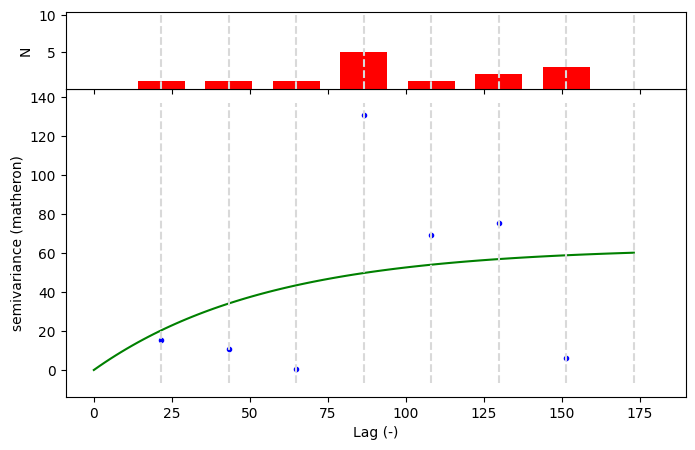

In [22]:
V1 = skg.Variogram(
    lyr1[['easting', 'northing']].values, 
    lyr1['Kh (m/day)'].values.flatten(), 
    maxlag=0.9, 
    n_lags=8, 
    normalize=False, 
    model='exponential'
    )

fig = V1.plot()

In [23]:
print(f"the correlation length based on the automatic data (poor) fitting is: {V1.describe()['effective_range']} meters")

the correlation length based on the automatic data (poor) fitting is: 166.11090288613792 meters


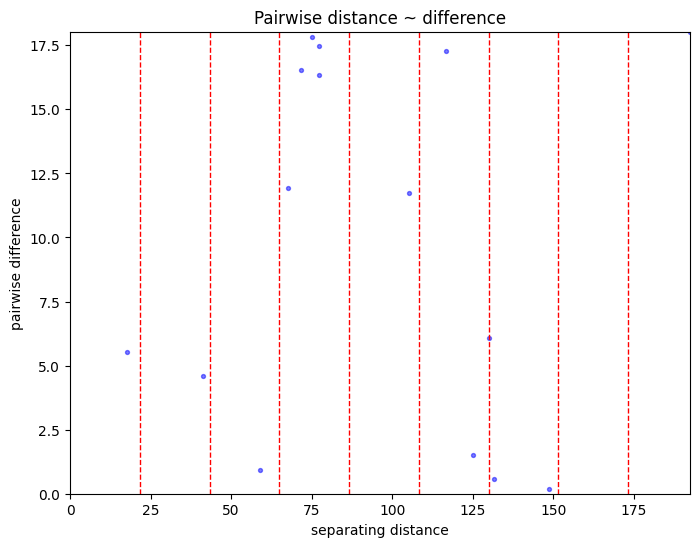

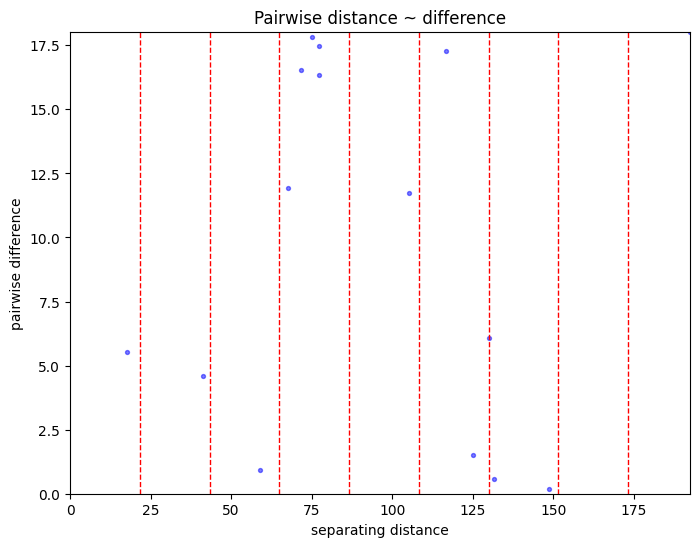

In [24]:
V1.distance_difference_plot(show=False)

In [25]:
ok1 = skg.OrdinaryKriging(V1, min_points=1, mode='exact')
x = lyr1[['easting', 'northing']].values[:, 0]
y = lyr1[['easting', 'northing']].values[:, 1]
xx, yy = np.mgrid[x.min():x.max():200j, y.min():y.max():200j]
field1 = ok1.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)
s2 = ok1.sigma.reshape(xx.shape)

In [26]:
interpolator = RegularGridInterpolator(
    (xx[:, 0], yy[0, :]), 
    field1, 
    method='nearest', 
    bounds_error=False, 
    #fill_value=10.848392, 
    fill_value=None, 
    )
sample_coords1 = np.column_stack([df_pp1['x'].values, df_pp1['y'].values])
sampled_values1 = interpolator(sample_coords1)

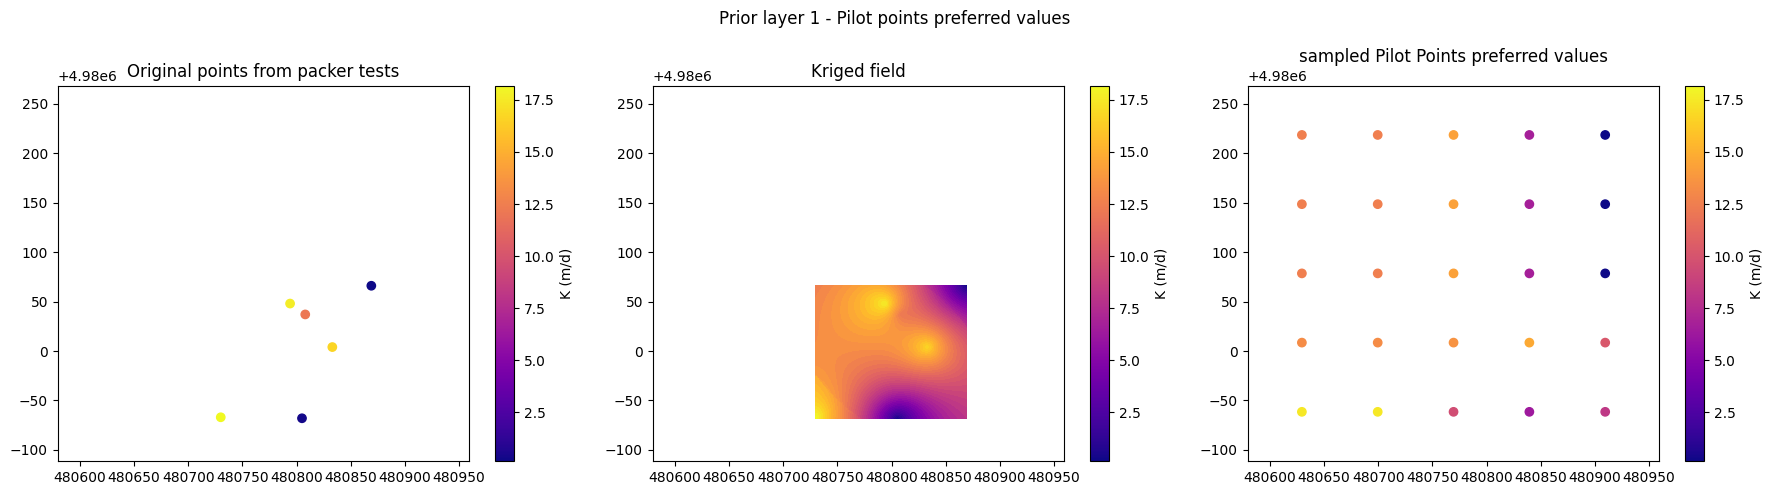

In [27]:
x_min, x_max = df_pp1['x'].min() - 50, df_pp1['x'].max() + 50
y_min, y_max = df_pp1['y'].min() - 50, df_pp1['y'].max() + 50

vmin = min(lyr1['Kh (m/day)'].min(), field1.min(), sampled_values1.min())
vmax = max(lyr1['Kh (m/day)'].max(), field1.max(), sampled_values1.max())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#original data packer test
sc1 = ax1.scatter(
    lyr1['easting'], lyr1['northing'], 
    c=lyr1['Kh (m/day)'], 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax1.set_title('Original points from packer tests')
plt.colorbar(sc1, ax=ax1, label='K (m/d)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

#kriged field
sc2 = ax2.contourf(
    np.linspace(x.min(),x.max(),200), 
    np.linspace(y.min(),y.max(),200), 
    field1.T, 
    origin='lower', cmap='plasma', 
    vmin=vmin, vmax=vmax, 
    levels=50
    )
ax2.set_title('Kriged field')
plt.colorbar(sc1, ax=ax2, label='K (m/d)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

sc3 = ax3.scatter(
    df_pp1['x'], df_pp1['y'], 
    #c=df_pp1['parval1'], 
    c=sampled_values1, 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax3.set_title('sampled Pilot Points preferred values')
plt.colorbar(sc3, ax=ax3, label='K (m/d)')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Plot interpolated points
fig.suptitle('Prior layer 1 - Pilot points preferred values')

plt.tight_layout()
plt.show()

asserting pilot point file was created

In [28]:
pp1_file = os.path.join(template_ws, "k_layer1_inst0pp.dat")
assert os.path.exists(pp1_file)

In [29]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


updating initial value + parameter bounds based on prior data uncertainty

In [30]:
df_pp1['parval1'] = sampled_values1
par_bnd_len = np.std(np.log(lyr1['Kh (m/day)'].values))*4
parlbnd = np.log(df_pp1['parval1'].values) - (par_bnd_len/2)
parubnd = np.log(df_pp1['parval1'].values) + (par_bnd_len/2)
df_pp1['parlbnd'] = 10**parlbnd
df_pp1['parubnd'] = 10**parubnd

In [31]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,12.543329,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.031977,log,3.577192e+06,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,12.543329,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.031977,log,3.577192e+06,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,14.245595,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.042864,log,4.795136e+06,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,6.692150,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.007526,log,8.419539e+05,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,0.156380,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,PMW-6_template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.000001,log,1.475322e+02,1.0,pilotpoints


In [32]:
len(df_pp1)

25

pilot points locations

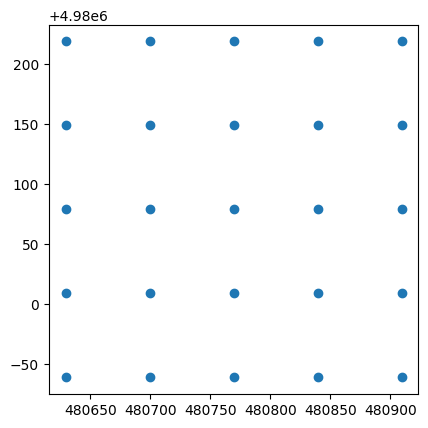

In [33]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
#ax.pcolormesh(sr.xcentergrid, sr.ycentergrid, ib)
ax.scatter(df_pp1.x, df_pp1.y)

adding parameter to layer 2 (BPP): constant K for now

In [34]:
df_cst = pf.add_parameters(
    "k_layer2.txt", 
    par_type='constant', 
    par_name_base="k_layer2", 
    pargp="k_layer2", 
    #initial_value=gwf.npf.k.array[1][0][0],
    initial_value=100,
    lower_bound=0.001, upper_bound=10000, 
    ult_ubound=10000, ult_lbound=0.0001, 
    )

2025-10-30 12:33:20.451619 transform was not passed, setting default transform to 'log'
2025-10-30 12:33:20.452622 starting: adding constant type m style parameters for file(s) ['k_layer2.txt']
2025-10-30 12:33:20.452622 starting: loading array PMW-6_template\k_layer2.txt
2025-10-30 12:33:20.494548 finished: loading array PMW-6_template\k_layer2.txt took: 0:00:00.041926
2025-10-30 12:33:20.494548 loaded array 'PMW-6_mf6\k_layer2.txt' of shape (388, 388)
2025-10-30 12:33:20.637058 starting: writing array-style template file 'PMW-6_template\k_layer2_inst0_constant.csv.tpl'
2025-10-30 12:33:20.637058 starting: writing template file PMW-6_template\k_layer2_inst0_constant.csv.tpl for ['k_layer2_inst:0']
2025-10-30 12:33:21.558056 finished: writing template file PMW-6_template\k_layer2_inst0_constant.csv.tpl for ['k_layer2_inst:0'] took: 0:00:00.920998
2025-10-30 12:33:21.558056 starting: writing array-based template file 'PMW-6_template\k_layer2_inst0_constant.csv.tpl'
2025-10-30 12:33:21.6

Adding parameter to layer 3: pilot points

In [35]:
#starting by getting array of idomain for the layer 0. this contain information of inactive cell to avoid placing pilot points
ib3 = gwf.dis.idomain.array[2]
plt.imshow(ib3)

TypeError: 'NoneType' object is not subscriptable

In [36]:
df_pp3 = pf.add_parameters(
    'k_layer3.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer3", 
    #pargp="hk0", 
    #zone_array=ib, #to be added when inactivating some cells

    geostruct=pp_gs, #geostructure of the pilot points #for interpolate from pp to model grid 
    #USING THE SAME STRUCTURE AS LAYER 1 (ABOVE BPP)

    #lower_bound=0.01, upper_bound=1000, 
    #ult_ubound=1000, ult_lbound=0.001,
    pp_space=70
)

2025-10-30 12:33:27.005868 transform was not passed, setting default transform to 'log'
2025-10-30 12:33:27.005868 starting: adding pilotpoints type m style parameters for file(s) ['k_layer3.txt']
2025-10-30 12:33:27.005868 finished: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:200.0,anisotropy:1.0,bearing:0.0
 took: 0:02:09.338079
2025-10-30 12:33:27.006865 starting: loading array PMW-6_template\k_layer3.txt
2025-10-30 12:33:27.062008 finished: loading array PMW-6_template\k_layer3.txt took: 0:00:00.055143
2025-10-30 12:33:27.062008 loaded array 'PMW-6_mf6\k_layer3.txt' of shape (388, 388)
2025-10-30 12:33:27.184303 starting: writing array-style template file 'PMW-6_template\k_layer3_inst0_pilotpoints.csv.tpl'
2025-10-30 12:33:27.184303 starting: setting up pilot point parameters
2025-10-30 12:33:27.184303 WARNING: Directly passing 'pp_space' has been deprecated and will eventually be removed, please use pp_options['pp_space'] instead.
2025-10-30 12

In [37]:
df_pp3.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


Importing packer test data for layer 3

In [38]:
df_packers = pd.read_excel('../../../data/MODFLOW_layers_priors.xlsx')
lyr3 = df_packers[df_packers['layer'] == 3]
lyr3 = lyr3.dropna(subset=['easting', 'northing', 'Kh (m/day)']) #dropping nans
lyr3 = lyr3.drop(8) #dropping PZ-2, data not reliable
lyr3 #packer data for layer 1

,borehole,northing,easting,layer,Kh (m/day),source,notes
2,PW-1,4980066,480869,3,0.042080,"packer test (PEER, 1999)",NaN
11,94-02,4980038,480890,3,0.209863,"packer test (CNA, 1997)","average between (0.37042, 0.17790, 0.15445, 0.13668)"
14,94-07,4980198,480782,3,0.237867,"packer test (CNA, 1997)","average between (0.27337, 0.23365, 0.20658)"
17,94-08,4979864,480711,3,0.288900,"packer test (CNA, 1997)","average between (0.30866, 0.42640, 0.13164)"
20,94-09,4979900,480919,3,3.274515,"packer test (CNA, 1997)","average between (12.30757, 0.22225, 0.19762, 0.37062)"
23,94-10,4979932,480805,3,0.149703,"packer test (CNA, 1997)","average between (0.16944, 0.14803, 0.13164)"
26,94-11,4980004,480833,3,0.879843,"packer test (CNA, 1997)","average between (0.07402, 1.01561, 1.54990)"
29,94-16,4979933,480730,3,0.458860,"packer test (CNA, 1997)","average between (1.51673, 0.11113, 0.10162, 0.10596)"


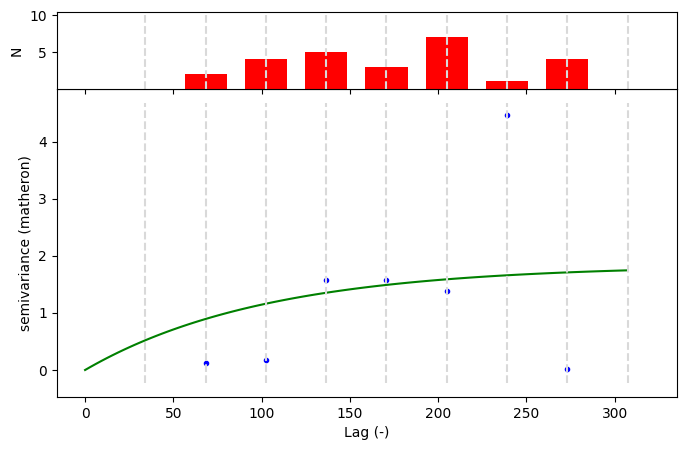

In [39]:
V3 = skg.Variogram(
    lyr3[['easting', 'northing']].values, 
    lyr3['Kh (m/day)'].values.flatten(), 
    maxlag=0.9, 
    n_lags=9, 
    normalize=False, 
    model='exponential'
    )

fig = V3.plot()

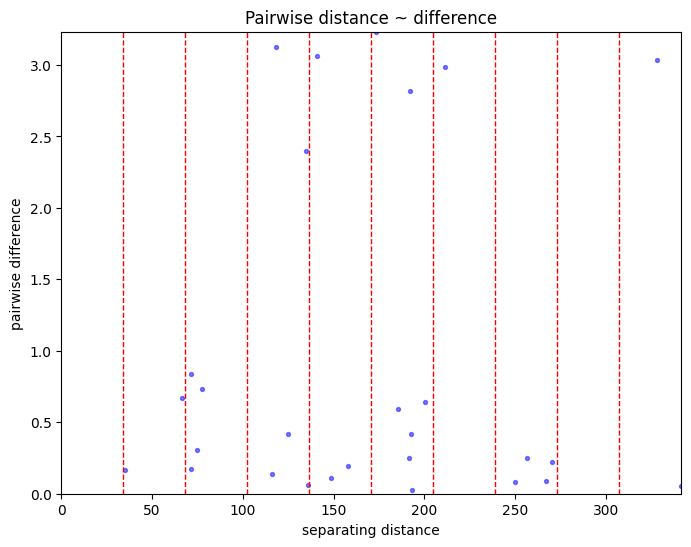

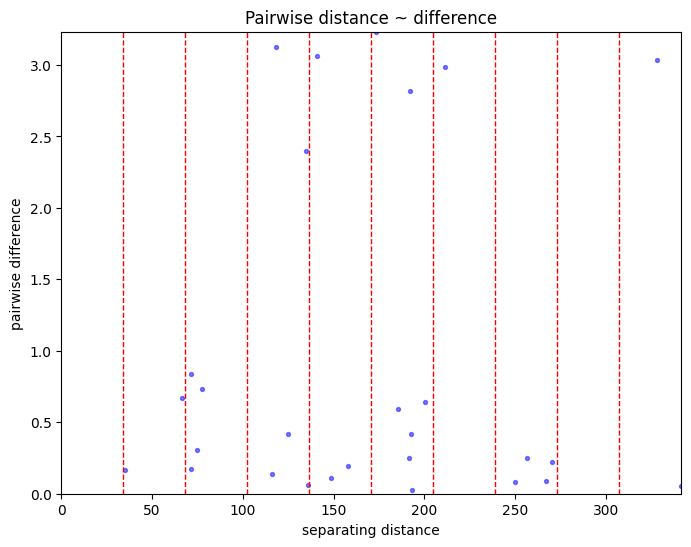

In [40]:
V3.distance_difference_plot(show=False)

In [41]:
print(f"the correlation length for layer 3 based on the packer test data is: {V3.describe()['effective_range']}")

the correlation length for layer 3 based on the packer test data is: 307.31672587088383


In [42]:
ok3 = skg.OrdinaryKriging(V3, min_points=1, mode='exact')
x = lyr3[['easting', 'northing']].values[:, 0]
y = lyr3[['easting', 'northing']].values[:, 1]
xx, yy = np.mgrid[x.min():x.max():200j, y.min():y.max():200j]
field3 = ok3.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)
s2 = ok3.sigma.reshape(xx.shape)

In [43]:
interpolator = RegularGridInterpolator(
    (xx[:, 0], yy[0, :]), 
    field3, 
    method='nearest', 
    bounds_error=False, 
    #fill_value=10.848392, 
    fill_value=None, 
    )
sample_coords3 = np.column_stack([df_pp3['x'].values, df_pp3['y'].values])
sampled_values3 = interpolator(sample_coords3)

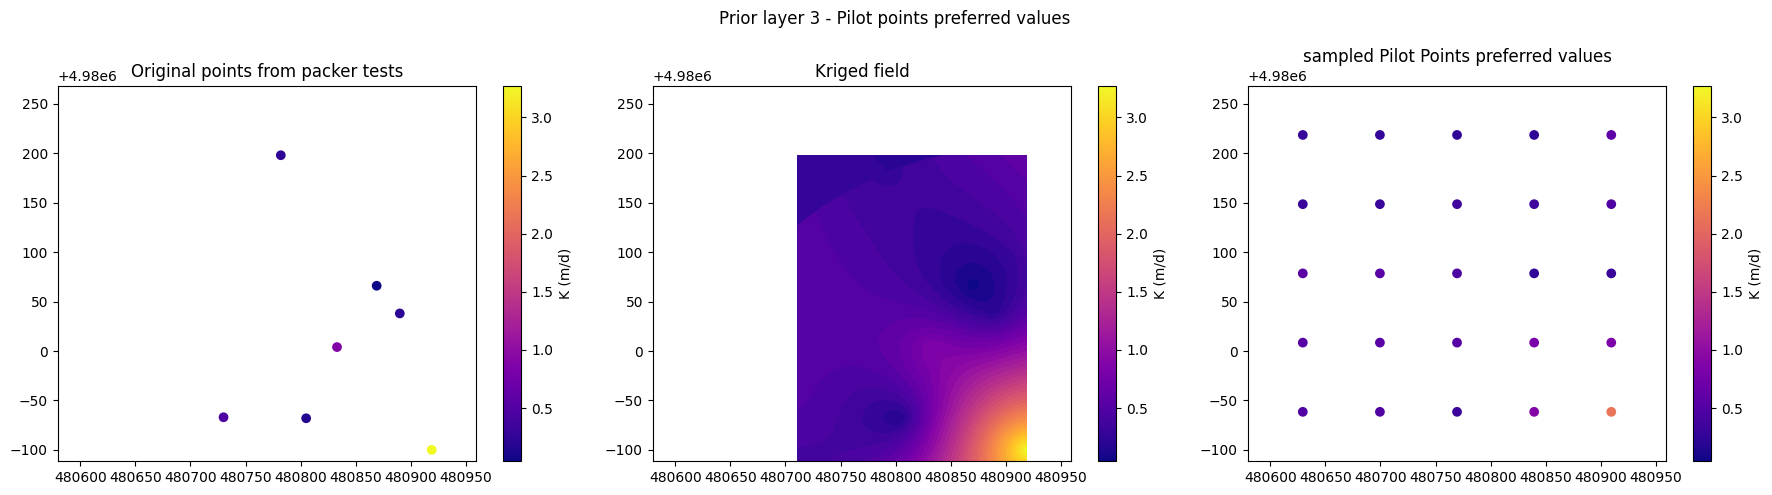

In [44]:
x_min, x_max = df_pp1['x'].min() - 50, df_pp1['x'].max() + 50
y_min, y_max = df_pp1['y'].min() - 50, df_pp1['y'].max() + 50

vmin = min(lyr3['Kh (m/day)'].min(), field3.min(), sampled_values3.min())
vmax = max(lyr3['Kh (m/day)'].max(), field3.max(), sampled_values3.max())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#original data packer test
sc1 = ax1.scatter(
    lyr3['easting'], lyr3['northing'], 
    c=lyr3['Kh (m/day)'], 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax1.set_title('Original points from packer tests')
plt.colorbar(sc1, ax=ax1, label='K (m/d)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

#kriged field
sc2 = ax2.contourf(
    np.linspace(x.min(),x.max(),200), 
    np.linspace(y.min(),y.max(),200), 
    field3.T, 
    origin='lower', cmap='plasma', 
    vmin=vmin, vmax=vmax, 
    levels=50
    )
ax2.set_title('Kriged field')
plt.colorbar(sc1, ax=ax2, label='K (m/d)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

sc3 = ax3.scatter(
    df_pp1['x'], df_pp1['y'], 
    #c=df_pp1['parval1'], 
    c=sampled_values3, 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax3.set_title('sampled Pilot Points preferred values')
plt.colorbar(sc3, ax=ax3, label='K (m/d)')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Plot interpolated points
fig.suptitle('Prior layer 3 - Pilot points preferred values')

plt.tight_layout()
plt.show()

In [45]:
pp3_file = os.path.join(template_ws, "k_layer1_inst0pp.dat")
assert os.path.exists(pp3_file)

updating layer index, initial value, and pilot points parameter bounds

In [46]:
df_pp3['k'] = 2
df_pp3['parval1'] = sampled_values3
par_bnd_len = np.std(np.log(lyr3['Kh (m/day)'].values))*4
parlbnd = np.log(df_pp3['parval1'].values) - (par_bnd_len/2)
parubnd = np.log(df_pp3['parval1'].values) + (par_bnd_len/2)
df_pp3['parlbnd'] = 10**parlbnd
df_pp3['parubnd'] = 10**parubnd

In [47]:
df_pp3.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,0.281720,2,35,35,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000215,log,13.619634,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,0.281720,2,35,105,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000215,log,13.619634,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,0.248252,2,35,175,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000161,log,10.178738,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,0.224927,2,35,245,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000128,log,8.110130,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,0.589716,2,35,315,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,PMW-6_template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.001177,log,74.626218,1.0,pilotpoints


Adding mf6 to the command script

In [48]:
pf.mod_sys_cmds.append("mf6") #do this only once
pf.mod_sys_cmds

['mf6']

adding the processing MODFLOW output in the PEST running script. 

This processing script reads the MODFLOW simulation output (heads for all well in all simulation time steps), and sample heads only for desired times (i.e. times that we have field data) using interpolation, then overwrites the heads.csv (MODFLOW output) used to compared with the observation data added to the PEST control file.

In [49]:
pf.add_py_function("helpers.py","process_heads_csv()",is_pre_cmd=False)

building pst

In [50]:
pst = pf.build_pst()

2025-10-30 12:34:18.174452 starting: Converting parameters to shortnames
2025-10-30 12:34:18.178451 starting: Renaming parameters for shortnames
2025-10-30 12:34:23.058974 finished: Renaming parameters for shortnames took: 0:00:04.880523
2025-10-30 12:34:23.080117 finished: Converting parameters to shortnames took: 0:00:04.905665
2025-10-30 12:34:23.080117 starting: Converting observations to shortnames
2025-10-30 12:34:23.080117 starting: Renaming observations for shortnames
2025-10-30 12:34:28.207178 finished: Renaming observations for shortnames took: 0:00:05.127061
2025-10-30 12:34:28.229085 finished: Converting observations to shortnames took: 0:00:05.148968
noptmax:0, npar_adj:51, nnz_obs:48
2025-10-30 12:34:28.272603 forward_run line:pyemu.os_utils.run(r'mf6')



checking parameter groups and data

In [51]:
pst.parameter_groups

,pargpnme,inctyp,derinc,derinclb,forcen,derincmul,dermthd,splitthresh,splitreldiff,splitaction
pargpnme,,,,,,,,,,
pg0,pg0,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg2,pg2,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg1,pg1,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller


In [52]:
pst.parameter_data.sample(5)

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,longname,shortname,pglong,i,inst,j,pname,pstyle,ptype,zone
p3,p3,log,factor,6.692150,0.007526,8.419539e+05,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,p3,k_layer1_inst:0,35,0,245,k,m,pp,1
p48,p48,log,factor,0.323062,0.000294,1.866787e+01,pg2,1.0,0.0,1,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:315_j:175_zone:1,p48,k_layer3_inst:0,315,0,175,k,m,pp,1
p16,p16,log,factor,13.198280,0.035953,4.021978e+06,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:245_j:105_zone:1,p16,k_layer1_inst:0,245,0,105,k,m,pp,1
p28,p28,log,factor,0.248252,0.000161,1.017874e+01,pg2,1.0,0.0,1,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,p28,k_layer3_inst:0,35,0,175,k,m,pp,1
p0,p0,log,factor,12.543329,0.031977,3.577192e+06,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,p0,k_layer1_inst:0,35,0,35,k,m,pp,1


## checking phimlim for investigation of minimum phi

In [53]:
pst.reg_data.phimlim

'1.0e-10'

minimum phi should be equal to the number of non-zero weighted observations

THIS ASSUMES THAT ALL MODEL-TO-MEASUREMENT MISFIT IS DUE TO MEASUREMENT UNCERTAINTY. In practice model error usually plays a larger role

In [54]:
pst.nnz_obs

48

aasigning PHILIM equal to the number of non-zero weighted observations

In [57]:
pst.reg_data.phimlim = pst.nnz_obs
pst.reg_data.phimlim

48

When changing PHIMLIM, we must also change PHIMACCEPT. this is the level of acceptable "measurement objective function".

If PEST achieves PHIMLIM, it will then attempt to minimize the regularization objective function, whiilst maintaining the measurement objective function below PHIMACCEPT

In [55]:
#setting PHIMACCEPT 10% higher than PHIMLIM
pst.reg_data.phimaccept = float(pst.reg_data.phimlim) * 1.1
pst.reg_data.phimaccept

1.1000000000000001e-10

changing PESTMODE to regularization

In [56]:
pst.control_data.pestmode = 'regularization'
pst.control_data.pestmode

'regularization'

updating the maximum number of PEST iteration

In [57]:
pst.control_data.noptmax = 15
pst.control_data.noptmax

np.int32(15)

In [58]:
print(f'there are {pst.nobs} field observation')

there are 48 field observation


changing observation names to meet the PEST version 1 character limit

In [59]:
print('current observation names:')
pst.obs_names[:5]

current observation names:


['ob0', 'ob1', 'ob2', 'ob3', 'ob4']


Each observation group correspond to a well in a injection test. So observation in the same well (and zone) during the same injection test are grouped together

In [60]:
pst.observation_data.head()

,obsnme,obsval,weight,obgnme,longname,shortname,oglong,oname,otype,time,usecol
ob0,ob0,0.005726,1.0,obg0,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,ob0,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.010417,head
ob1,ob1,0.016650,1.0,obg0,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,ob1,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.020833,head
ob2,ob2,0.033832,1.0,obg0,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,ob2,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.041667,head
ob3,ob3,0.050680,1.0,obg0,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,ob3,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.0625,head
ob4,ob4,0.021026,1.0,obg1,oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,ob4,oname:heads.csv_otype:lst_usecol:head_ow23p,heads.csv,lst,0.010417,head


Checking input and output model files

In [61]:
pst.model_input_data

,pest_file,model_file
k_layer1_inst0pp.dat.tpl,k_layer1_inst0pp.dat.tpl,k_layer1_inst0pp.dat
k_layer2_inst0_constant.csv.tpl,k_layer2_inst0_constant.csv.tpl,mult\k_layer2_inst0_constant.csv
k_layer3_inst0pp.dat.tpl,k_layer3_inst0pp.dat.tpl,k_layer3_inst0pp.dat


In [62]:
pst.model_output_data

,pest_file,model_file
heads.csv.ins,heads.csv.ins,heads.csv


Adding priors

In [63]:
pst.prior_information #no prior info up to now

,pilbl,obgnme,equation,weight


In [64]:
pst.parameter_groups

,pargpnme,inctyp,derinc,derinclb,forcen,derincmul,dermthd,splitthresh,splitreldiff,splitaction
pargpnme,,,,,,,,,,
pg0,pg0,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg2,pg2,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg1,pg1,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller


adding preferred-value equations, currently only for layer 1 and 2

In [65]:
#applying preferred value regularization on all parameters
pyemu.helpers.zero_order_tikhonov(
    pst, parbounds=True, #using parameter bounds to specify prior information equation weights
    par_groups=['pg0', 'pg1', 'pg2'], #adding preferred-value only for pp in layer 1 and 3
    ) #setting up preferred-value regularization in the pest control file


In [68]:
pst.prior_information.sample(5)

,pilbl,equation,obgnme,weight
pilbl,,,,
p31,p31,1.0 * log(p31) = -5.252299E-01,regulpg2,0.208246
p41,p41,1.0 * log(p41) = -2.630953E-01,regulpg2,0.208246
p25,p25,1.0 * log(p25) = 2.000000E+00,regulpg1,0.142857
p3,p3,1.0 * log(p3) = 8.255656E-01,regulpg0,0.124244
p26,p26,1.0 * log(p26) = -5.501817E-01,regulpg2,0.208246


adding preferred-difference equations

creating geostatistical structure based on field data (packer and slug tests)

* layer 1: packer
* BPP: not applied yet
* layer 3: packer

Layer 1 - creating variogram using correlation length from packer test data

In [69]:
print(f"The estimated sill: {V1.describe()['sill']}")
print(f"Estimated correlation length: {V1.describe()['effective_range']}")

The estimated sill: 62.953338113333665
Estimated correlation length: 166.11090288613792


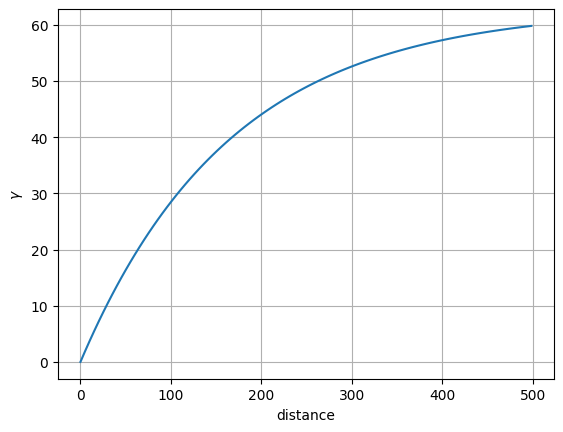

In [70]:
v1 = pyemu.geostats.ExpVario(contribution=62.95, a=166.11)
gs1 = pyemu.geostats.GeoStruct(variograms=v1, nugget=0.0)
ax = gs1.plot()
ax.grid()


obtaining pilot points location from pilot points template file

In [71]:
df_pp1 = pyemu.pp_utils.pp_tpl_to_dataframe(os.path.join(template_ws, "k_layer1_inst0pp.dat.tpl"))
#df_pp1['parnme'] = [f'p{i}' for i in range(len(df_pp1['parnme']))]
df_pp1.head()

,name,x,y,zone,parnme
0,pp_0000,480629.50046,4.980219e+06,1,p0
1,pp_0001,480699.50046,4.980219e+06,1,p1
2,pp_0002,480769.50046,4.980219e+06,1,p2
3,pp_0003,480839.50046,4.980219e+06,1,p3
4,pp_0004,480909.50046,4.980219e+06,1,p4


In [72]:
pst.parameter_data.head()

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,longname,shortname,pglong,i,inst,j,pname,pstyle,ptype,zone
parnme,,,,,,,,,,,,,,,,,,,,
p0,p0,log,factor,12.543329,0.031977,3.577192e+06,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,p0,k_layer1_inst:0,35,0,35,k,m,pp,1
p1,p1,log,factor,12.543329,0.031977,3.577192e+06,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,p1,k_layer1_inst:0,35,0,105,k,m,pp,1
p2,p2,log,factor,14.245595,0.042864,4.795136e+06,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,p2,k_layer1_inst:0,35,0,175,k,m,pp,1
p3,p3,log,factor,6.692150,0.007526,8.419539e+05,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,p3,k_layer1_inst:0,35,0,245,k,m,pp,1
p4,p4,log,factor,0.156380,0.000001,1.475322e+02,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,p4,k_layer1_inst:0,35,0,315,k,m,pp,1


building a covariance matrix for the layer 1 pilot points by using the defined geostatistical structure

In [73]:
cov1 = gs1.covariance_matrix(df_pp1.x, df_pp1.y, df_pp1.parnme)
cov1.to_dataframe().head()

,p0,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,p11,p12,p13,p14,p15,p16,p17,p18,p19,p20,p21,p22,p23,p24
p0,62.950000,41.302922,27.099784,17.780783,11.666375,41.302922,34.687540,24.533633,16.605488,11.076582,27.099784,24.533633,19.113987,13.776089,9.561543,17.780783,16.605488,13.776089,10.532441,7.654573,11.666375,11.076582,9.561543,7.654573,5.803725
p1,41.302922,62.950000,41.302922,27.099784,17.780783,34.687540,41.302922,34.687540,24.533633,16.605488,24.533633,27.099784,24.533633,19.113987,13.776089,16.605488,17.780783,16.605488,13.776089,10.532441,11.076582,11.666375,11.076582,9.561543,7.654573
p2,27.099784,41.302922,62.950000,41.302922,27.099784,24.533633,34.687540,41.302922,34.687540,24.533633,19.113987,24.533633,27.099784,24.533633,19.113987,13.776089,16.605488,17.780783,16.605488,13.776089,9.561543,11.076582,11.666375,11.076582,9.561543
p3,17.780783,27.099784,41.302922,62.950000,41.302922,16.605488,24.533633,34.687540,41.302922,34.687540,13.776089,19.113987,24.533633,27.099784,24.533633,10.532441,13.776089,16.605488,17.780783,16.605488,7.654573,9.561543,11.076582,11.666375,11.076582
p4,11.666375,17.780783,27.099784,41.302922,62.950000,11.076582,16.605488,24.533633,34.687540,41.302922,9.561543,13.776089,19.113987,24.533633,27.099784,7.654573,10.532441,13.776089,16.605488,17.780783,5.803725,7.654573,9.561543,11.076582,11.666375


adding preferred-difference equations for layer 1 using the created covariance matrix to adjust weights

In [74]:
pyemu.helpers.first_order_pearson_tikhonov(pst, cov1, reset=False)

getting CC matrix
processing


In [75]:
pst.prior_information.tail(5)

,pilbl,equation,obgnme,weight
pilbl,,,,
pcc_347,pcc_347,1.0 * log(p21) - 1.0 * log(p23) = 0.0,regul_cc,0.430497
pcc_348,pcc_348,1.0 * log(p21) - 1.0 * log(p24) = 0.0,regul_cc,0.282459
pcc_349,pcc_349,1.0 * log(p22) - 1.0 * log(p23) = 0.0,regul_cc,0.656123
pcc_350,pcc_350,1.0 * log(p22) - 1.0 * log(p24) = 0.0,regul_cc,0.430497
pcc_351,pcc_351,1.0 * log(p23) - 1.0 * log(p24) = 0.0,regul_cc,0.656123


doing the same for Layer 3...

In [76]:
print(f"The estimated sill: {V3.describe()['sill']}")
print(f"Estimated correlation length: {V3.describe()['effective_range']}")

The estimated sill: 1.8365215710516174
Estimated correlation length: 307.31672587088383


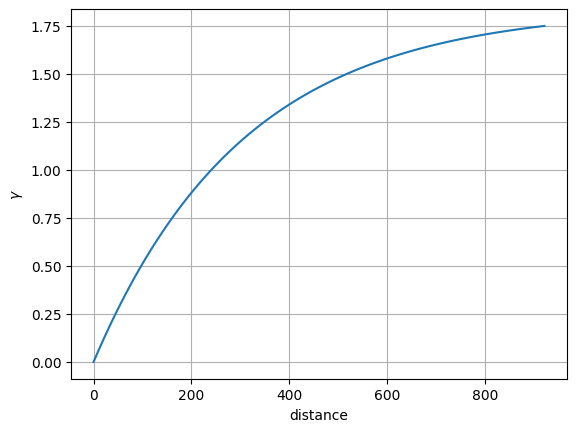

In [77]:
v3 = pyemu.geostats.ExpVario(contribution=1.84, a=307.32)
gs3 = pyemu.geostats.GeoStruct(variograms=v3, nugget=0.0)
ax = gs3.plot()
ax.grid()

In [78]:
df_pp3 = pyemu.pp_utils.pp_tpl_to_dataframe(os.path.join(template_ws, "k_layer3_inst0pp.dat.tpl"))
df_pp3.head()

,name,x,y,zone,parnme
0,pp_0000,480629.50046,4.980219e+06,1,p26
1,pp_0001,480699.50046,4.980219e+06,1,p27
2,pp_0002,480769.50046,4.980219e+06,1,p28
3,pp_0003,480839.50046,4.980219e+06,1,p29
4,pp_0004,480909.50046,4.980219e+06,1,p30


In [79]:
cov3 = gs3.covariance_matrix(df_pp3.x, df_pp3.y, df_pp3.parnme)
cov3.to_dataframe().head()

,p26,p27,p28,p29,p30,p31,p32,p33,p34,p35,p36,p37,p38,p39,p40,p41,p42,p43,p44,p45,p46,p47,p48,p49,p50
p26,1.840000,1.465197,1.166741,0.929079,0.739829,1.465197,1.333280,1.105662,0.895365,0.719372,1.166741,1.105662,0.966107,0.809377,0.664395,0.929079,0.895365,0.809377,0.700049,0.589128,0.739829,0.719372,0.664395,0.589128,0.507262
p27,1.465197,1.840000,1.465197,1.166741,0.929079,1.333280,1.465197,1.333280,1.105662,0.895365,1.105662,1.166741,1.105662,0.966107,0.809377,0.895365,0.929079,0.895365,0.809377,0.700049,0.719372,0.739829,0.719372,0.664395,0.589128
p28,1.166741,1.465197,1.840000,1.465197,1.166741,1.105662,1.333280,1.465197,1.333280,1.105662,0.966107,1.105662,1.166741,1.105662,0.966107,0.809377,0.895365,0.929079,0.895365,0.809377,0.664395,0.719372,0.739829,0.719372,0.664395
p29,0.929079,1.166741,1.465197,1.840000,1.465197,0.895365,1.105662,1.333280,1.465197,1.333280,0.809377,0.966107,1.105662,1.166741,1.105662,0.700049,0.809377,0.895365,0.929079,0.895365,0.589128,0.664395,0.719372,0.739829,0.719372
p30,0.739829,0.929079,1.166741,1.465197,1.840000,0.719372,0.895365,1.105662,1.333280,1.465197,0.664395,0.809377,0.966107,1.105662,1.166741,0.589128,0.700049,0.809377,0.895365,0.929079,0.507262,0.589128,0.664395,0.719372,0.739829


In [80]:
pyemu.helpers.first_order_pearson_tikhonov(pst, cov3, reset=False)

getting CC matrix
processing


checking prior information equations

In [81]:
pst.prior_information.tail(5)

,pilbl,equation,obgnme,weight
pilbl,,,,
pcc_647,pcc_647,1.0 * log(p47) - 1.0 * log(p49) = 0.0,regul_cc,0.634098
pcc_648,pcc_648,1.0 * log(p47) - 1.0 * log(p50) = 0.0,regul_cc,0.504934
pcc_649,pcc_649,1.0 * log(p48) - 1.0 * log(p49) = 0.0,regul_cc,0.796303
pcc_650,pcc_650,1.0 * log(p48) - 1.0 * log(p50) = 0.0,regul_cc,0.634098
pcc_651,pcc_651,1.0 * log(p49) - 1.0 * log(p50) = 0.0,regul_cc,0.796303


In [96]:
pst.pestpp_options.pop('n_iter_base')
pst.pestpp_options.pop('n_iter_super')

KeyError: 'n_iter_base'

overwritting pst file

In [82]:
pst.write(os.path.join(template_ws, 'PMW-6_mf6.pst'),version=1)

noptmax:15, npar_adj:51, nnz_obs:48


setting up agents for running PEST in parallel

In [83]:
#number of cores availables
psutil.cpu_count(logical=False)

10

In [84]:
#setting the number of workers
num_workers = 7

In [85]:
#run-manager directory folder (where the manager will be running), 
#outcomes of PEST will be recorded here in a different location than template_ws to avoid mistakes
m_d = 'master_pp'

when running from jupyter notebook slow things down a lot, it is better as the model get complex to run from command lines which is faster and more efficient

Starting workers and running PEST

In [86]:
pyemu.os_utils.start_workers(template_ws, # folder which contains the "template" PEST dataset
                            'pestpp-glm', #PEST software version we want to run
                            'PMW-6_mf6.pst', #PEST control file 
                            num_workers=num_workers, #how many agents to deploy
                            worker_root='.', #where to deploy the agent directories; relative to where python is running
                            master_dir=m_d, #manager directory where it will be running
                            verbose=True,
                            )

2025-10-30 12:37:02,630 - MainProcess - INFO - Reserved port 4475 for process 29276


master:pestpp-glm PMW-6_mf6.pst /h :4475 in master_pp
worker:pestpp-glm PMW-6_mf6.pst /h localhost:4475 in .\worker_0
worker:pestpp-glm PMW-6_mf6.pst /h localhost:4475 in .\worker_1
worker:pestpp-glm PMW-6_mf6.pst /h localhost:4475 in .\worker_2
worker:pestpp-glm PMW-6_mf6.pst /h localhost:4475 in .\worker_3
worker:pestpp-glm PMW-6_mf6.pst /h localhost:4475 in .\worker_4
worker:pestpp-glm PMW-6_mf6.pst /h localhost:4475 in .\worker_5
worker:pestpp-glm PMW-6_mf6.pst /h localhost:4475 in .\worker_6


Running PEST #old

In [74]:
#pyemu.os_utils.run('pestpp-glm PMW-6_mf6.pst', cwd=template_ws, verbose=True)

run():pestpp-glm.exe PMW-6_mf6.pst


plotting results

In [87]:
df_obj = pd.read_csv(os.path.join(m_d, "PMW-6_mf6.iobj"),index_col=0)
# echo out the dataframe
df_obj

,model_runs_completed,total_phi,measurement_phi,regularization_phi,obg0,obg1,obg2,obg3,obg4,obg5,obg6,obg7,obg8,obg9,obg10,obg11,regulpg0,regulpg1,regulpg2,regul_cc
iteration,,,,,,,,,,,,,,,,,,,,
0,0,0.546091,0.371600,1.744920e-01,0.000461,0.001297,0.002586,0.013752,0.119552,0.146915,0.000776,0.012909,0.005566,0.025087,0.012996,0.029703,5.816390e-02,0.000000e+00,5.816390e-02,5.816390e-02
1,67,0.428383,0.370219,5.816390e-02,0.000455,0.001255,0.002627,0.013650,0.119225,0.146460,0.000760,0.012708,0.005681,0.024827,0.013053,0.029517,8.123260e-12,1.755330e-10,9.990560e-14,5.816390e-02
2,133,0.371253,0.370219,1.034440e-03,0.000455,0.001255,0.002627,0.013650,0.119225,0.146460,0.000760,0.012708,0.005681,0.024827,0.013053,0.029517,0.000000e+00,5.172180e-04,1.282330e-10,5.172180e-04
3,253,0.367602,0.365657,1.945270e-03,0.000476,0.001236,0.002761,0.013278,0.117502,0.144526,0.000777,0.012410,0.005896,0.024352,0.013602,0.028841,1.347550e-18,1.936070e-03,4.599310e-06,4.599320e-06
4,376,0.366731,0.366707,2.436170e-05,0.000478,0.001251,0.002752,0.013389,0.117824,0.144859,0.000778,0.012483,0.005888,0.024468,0.013516,0.029021,2.426730e-05,3.146080e-08,3.146080e-08,3.146160e-08
5,502,0.318760,0.314822,3.938070e-03,0.000758,0.002088,0.003619,0.010012,0.095926,0.121172,0.001448,0.008524,0.009814,0.018217,0.022211,0.021032,3.937420e-03,6.494610e-07,8.503320e-10,8.366050e-10
6,628,0.314519,0.314519,4.353070e-09,0.000764,0.002093,0.003611,0.010002,0.095832,0.121028,0.001446,0.008518,0.009818,0.018151,0.022290,0.020967,1.088600e-09,1.088140e-09,1.088140e-09,1.088190e-09
7,754,0.314389,0.314389,4.352780e-09,0.000765,0.002094,0.003612,0.009976,0.095782,0.120989,0.001446,0.008507,0.009823,0.018137,0.022324,0.020935,1.088210e-09,1.088200e-09,1.088190e-09,1.088190e-09


array([<Axes: xlabel='iteration'>, <Axes: xlabel='iteration'>],
      dtype=object)

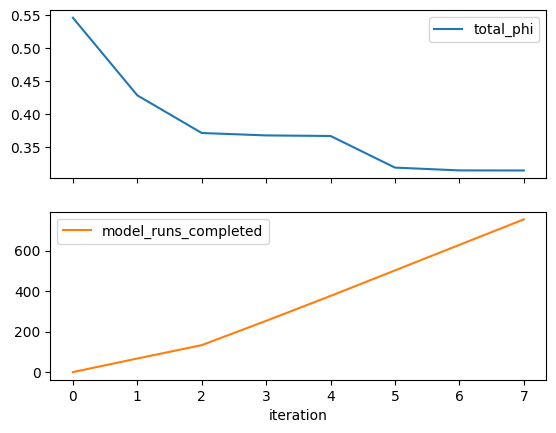

In [88]:
df_obj.loc[:,["total_phi","model_runs_completed"]].plot(subplots=True)

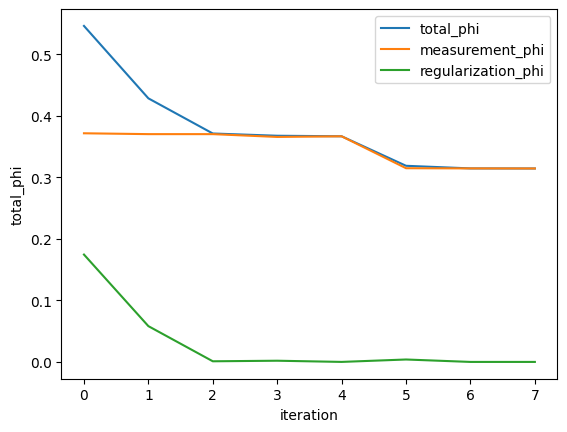

In [98]:
df_obj.plot(y=['total_phi','measurement_phi','regularization_phi'])
plt.ylabel('total_phi');

loading pst

In [89]:
pst = pyemu.Pst(os.path.join(m_d, 'PMW-6_mf6.pst'))

In [95]:
pst.phi

np.float64(0.314389256997299)

Estimated K values:

In [99]:
pst.parrep(os.path.join(m_d, "PMW-6_mf6.par" ))
pst.write_input_files(pst_path=m_d)
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer1_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer1.txt"))

Updating parameter values from master_pp\PMW-6_mf6.par
parrep: updating noptmax to 0


'master_pp\\k_layer1.txt'

Only run for layer 2 when having pilot points

In [ ]:
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer1_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer2.txt"))

In [100]:
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer3_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer3.txt"))

'master_pp\\k_layer3.txt'

In [101]:
pst.parameter_data.parval1

parnme
p0     44.400776
p1     14.977094
p2     12.334509
p3      6.691380
p4      0.373058
p5     14.061080
p6     12.547601
p7     14.233407
p8      6.642845
p9      0.155986
p10    10.094167
p11    12.544704
p12    14.251901
p13     6.692098
p14     0.156386
p15    18.732809
p16    17.427585
p17    13.587732
p18    21.893830
p19    10.168137
p20    11.586736
p21    13.960128
p22     9.550880
p23     7.248021
p24     8.201321
p25    23.129883
p26     0.281720
p27     0.281720
p28     0.248252
p29     0.224927
p30     0.589716
p31     0.298380
p32     0.298380
p33     0.367494
p34     0.346083
p35     0.479780
p36     0.551289
p37     0.551289
p38     0.457583
p39     0.240521
p40     0.304869
p41     0.545638
p42     0.545638
p43     0.527445
p44     0.809666
p45     0.845542
p46     0.476931
p47     0.476931
p48     0.323062
p49     0.912192
p50     2.147027
Name: parval1, dtype: float64

In [91]:
import seaborn as sns

<Axes: >

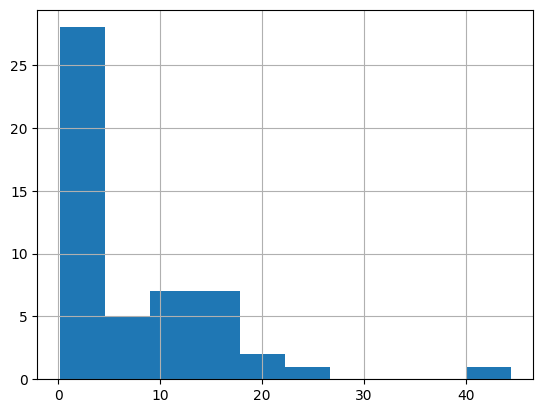

In [102]:
pst.parameter_data.parval1.hist()

In [103]:
pst.parameter_data.head()

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,extra,longname,i,inst,j,pname,pstyle,ptype,zone
parnme,,,,,,,,,,,,,,,,,,,
p0,p0,log,factor,44.400776,0.031977,3.577192e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,35,0,35,k,m,pp,1
p1,p1,log,factor,14.977094,0.031977,3.577192e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,35,0,105,k,m,pp,1
p2,p2,log,factor,12.334509,0.042864,4.795136e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,35,0,175,k,m,pp,1
p3,p3,log,factor,6.691380,0.007526,8.419539e+05,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,35,0,245,k,m,pp,1
p4,p4,log,factor,0.373058,0.000001,1.475322e+02,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,35,0,315,k,m,pp,1


<Axes: xlabel='parval1', ylabel='Count'>

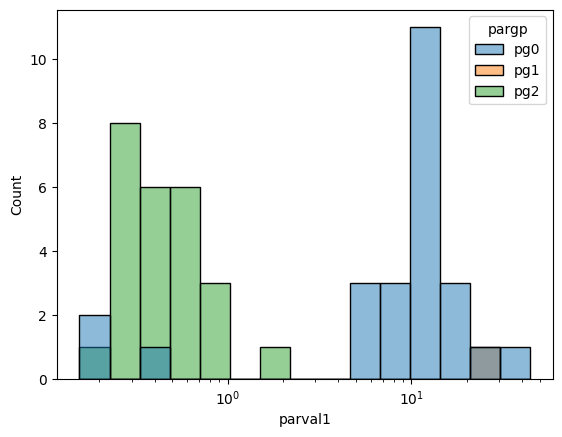

In [112]:
sns.histplot(data=pst.parameter_data, x='parval1', hue='pargp', bins=15, log_scale=True)

In [108]:
estimated_parameters = pst.parameter_data.copy()
10**(estimated_parameters.loc[estimated_parameters['partrans'] == 'log', 'parval1'])


parnme
p0     3.494053e+12
p1     3.494053e+12
p2     1.760332e+14
p3     4.922090e+06
p4     1.433442e+00
p5     3.494053e+12
p6     3.494053e+12
p7     1.760332e+14
p8     4.922090e+06
p9     1.433442e+00
p10    3.494053e+12
p11    3.494053e+12
p12    1.760332e+14
p13    4.922090e+06
p14    1.433442e+00
p15    1.578630e+13
p16    1.578630e+13
p17    3.840001e+13
p18    5.222278e+14
p19    1.468152e+10
p20    2.640122e+17
p21    2.640122e+17
p22    3.551992e+09
p23    2.149429e+06
p24    1.588320e+08
p25    6.541841e+01
p26    1.913024e+00
p27    1.913024e+00
p28    1.771136e+00
p29    1.678523e+00
p30    3.887908e+00
p31    1.987835e+00
p32    1.987835e+00
p33    2.330739e+00
p34    2.218620e+00
p35    3.018423e+00
p36    3.558680e+00
p37    3.558680e+00
p38    2.868029e+00
p39    1.739885e+00
p40    2.017756e+00
p41    3.512676e+00
p42    3.512676e+00
p43    3.368566e+00
p44    6.451585e+00
p45    7.007167e+00
p46    2.998685e+00
p47    2.998685e+00
p48    2.104079e+00
p49    8.1694

plotting head results

In [105]:
res_nz = pst.res.loc[pst.nnz_obs_names,:]
# display res_nz to understand what we are doing
res_nz.head(4)

,name,group,measured,modelled,residual,weight
name,,,,,,
ob0,ob0,obg0,0.005726,0.020306,-0.014580,1.0
ob1,ob1,obg0,0.016650,0.033547,-0.016897,1.0
ob2,ob2,obg0,0.033832,0.048389,-0.014557,1.0
ob3,ob3,obg0,0.050680,0.058082,-0.007402,1.0


<Figure size 800x1050 with 0 Axes>

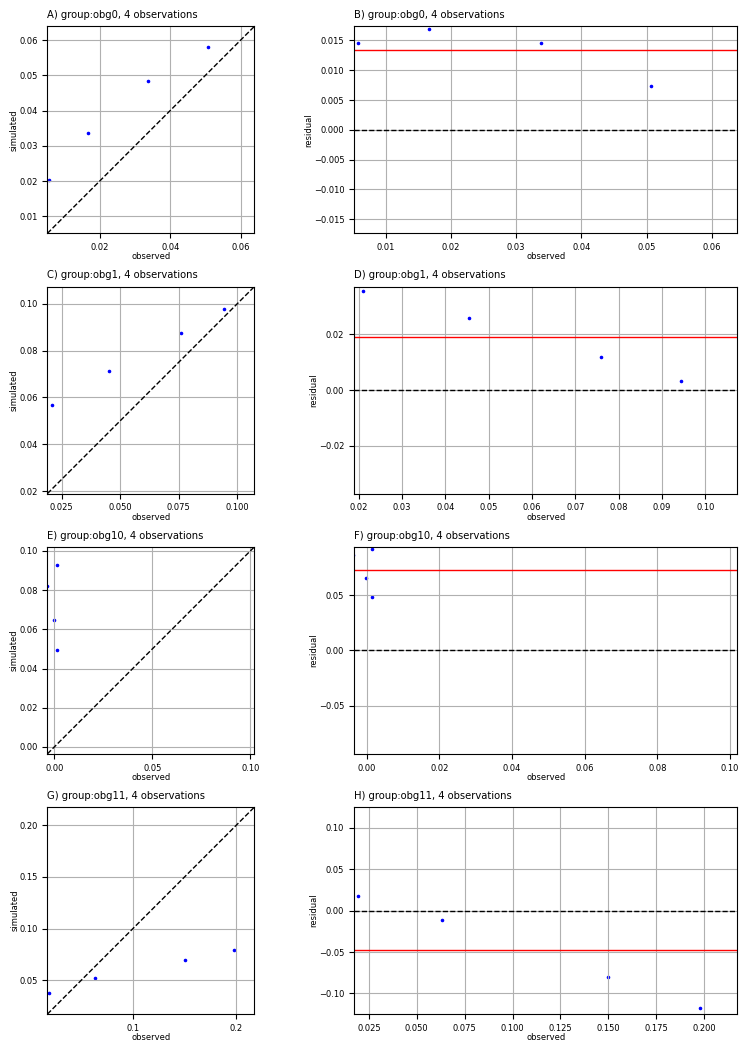

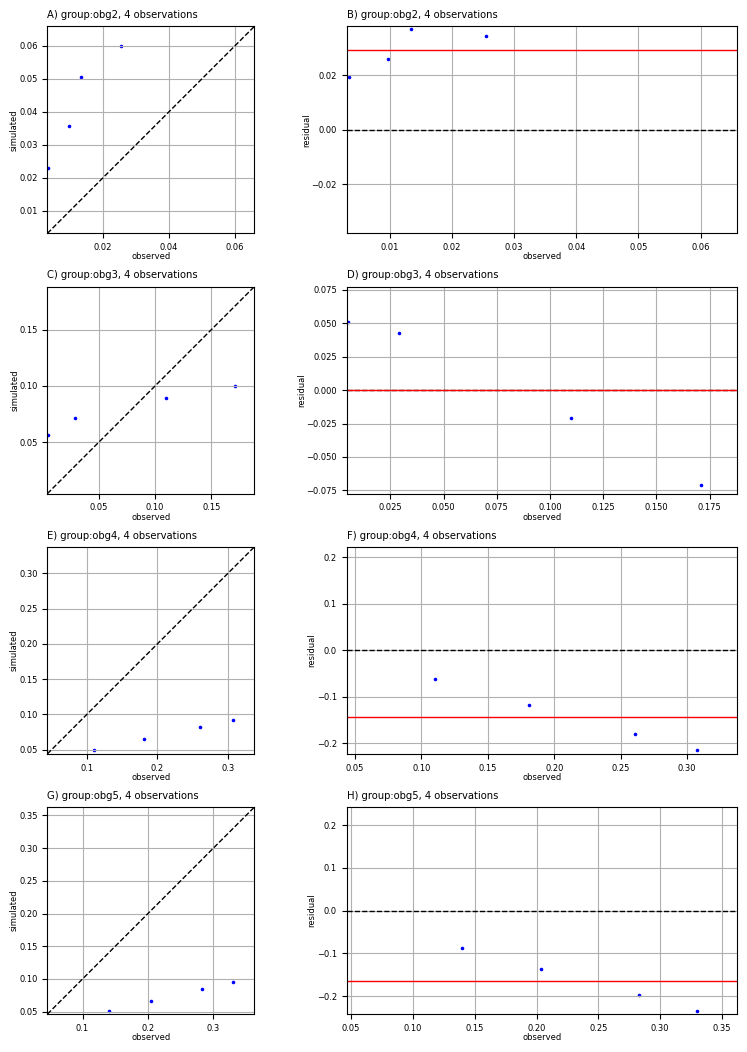

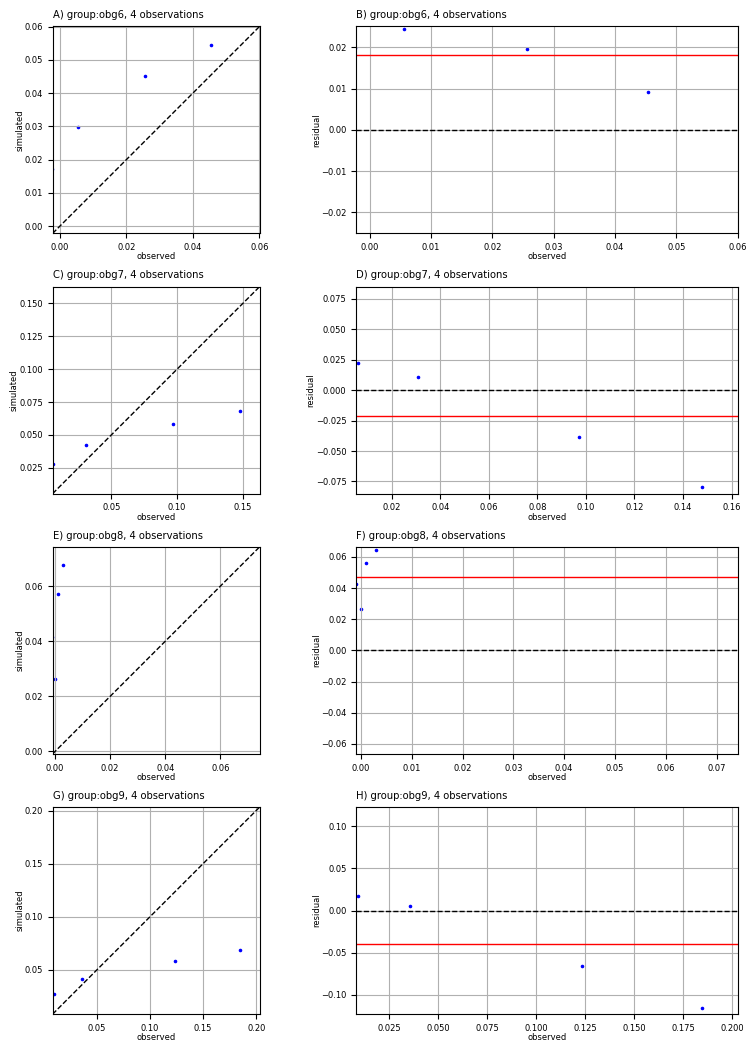

In [106]:
pyemu.plot_utils.res_1to1(pst);

In [ ]:
pst.phi

npar:51, npar_adj:51, nobs:48, nnzobs:48, filename:master_pp\PMW-6_mf6.pst

plotting estimated K field

In [107]:
sim = flopy.mf6.MFSimulation.load(sim_ws=m_d)
gwf = sim.get_model()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


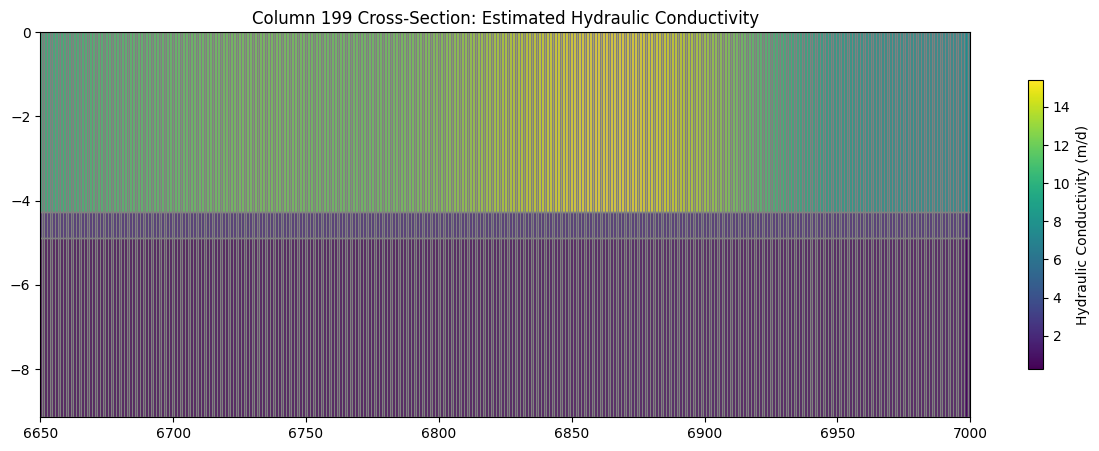

In [108]:
hk_array = gwf.npf.k.array

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(1, 1, 1)

# Create a PlotCrossSection object for a specific column
xsect = flopy.plot.PlotCrossSection(model=gwf, ax=ax, line={"Column": 199})

# Plot the hydraulic conductivity array on the cross-section
# The plot_array() method will display the values as colored patches
csa = xsect.plot_array(hk_array)

# Plot the model grid for context
linecollection = xsect.plot_grid()

# Add a color bar to interpret the hydraulic conductivity values
cb = plt.colorbar(csa, shrink=0.75, label="Hydraulic Conductivity (m/d)")

# Set the title and show the plot
ax.set_title("Column 199 Cross-Section: Estimated Hydraulic Conductivity")
ax.set_xlim(6650, 7000) # Assuming the same x-limits as your previous plot
plt.show()

whole field

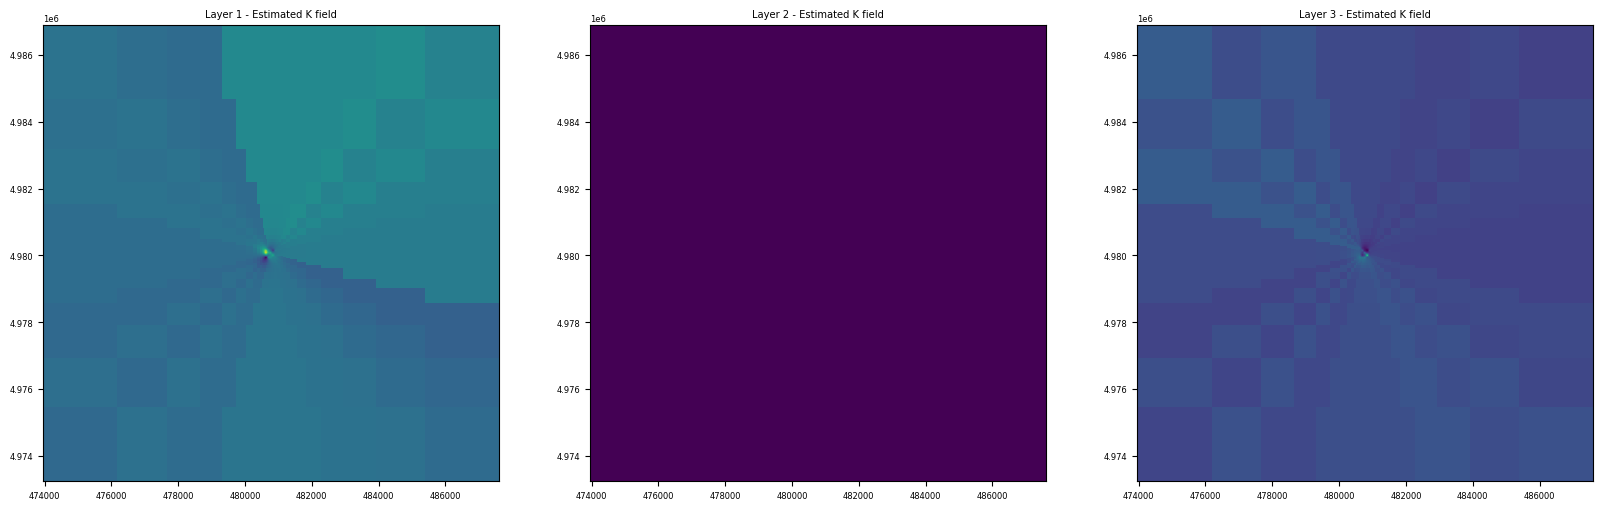

In [104]:
fig = plt.figure(figsize=(20, 20))
for i in range(3):
    
    ax = fig.add_subplot(1, 3, i+1, aspect='equal')

    # Create a PlotMapView object
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)

    # Plot the active and inactive cells
    # In MODFLOW 6, 'IDOMAIN' array is used instead of 'IBOUND'.
    # plot_ibound() handles this automatically.
    quadmesh = mapview.plot_array(hk_array[i]) # plots K field

    # Plot the grid lines for context
    #grid_lines = mapview.plot_grid()

    # Add a title and show the plot
    ax.set_title(f"Layer {i+1} - Estimated K field")
    #plt.show()

zoom at MLAC site

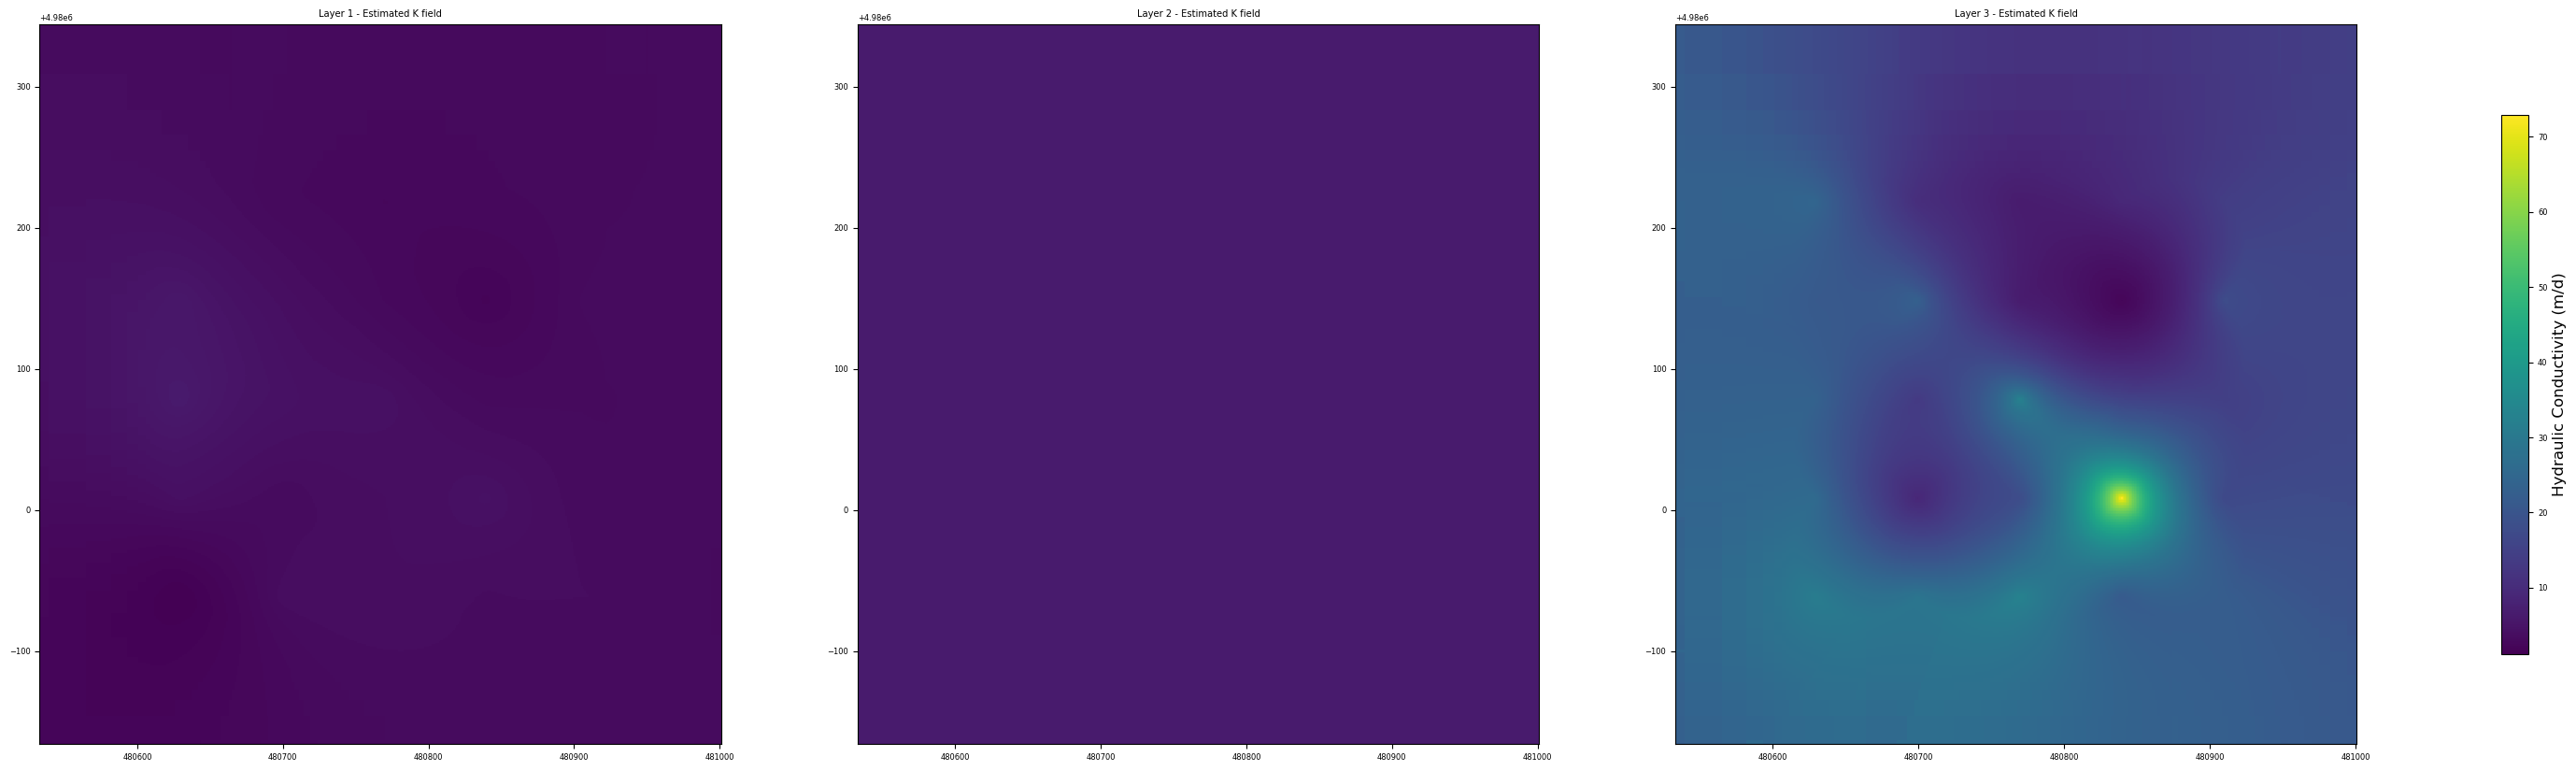

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(40,10))

# Optionally, determine common vmin and vmax for consistent color scaling
vmin = hk_array.min()
vmax = hk_array.max()

# Plot each layer
quadmesh_list = []
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    quadmesh = mapview.plot_array(hk_array[i], vmin=vmin, vmax=vmax)
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"Layer {i+1} - Estimated K field")
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
cbar = fig.colorbar(quadmesh_list[0], ax=axes, shrink=0.75, label="Hydraulic Conductivity (m/d)")
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=12)

plt.show()

debugging